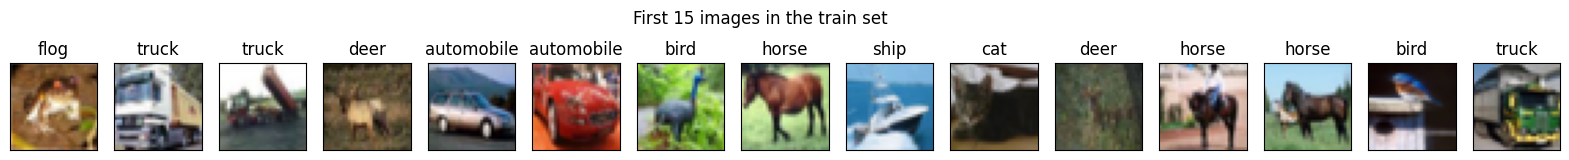

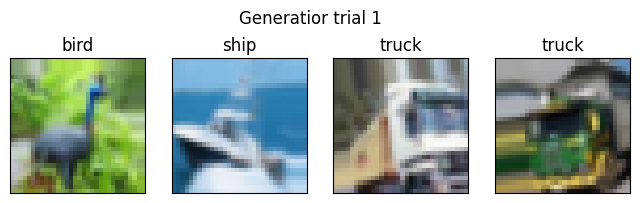

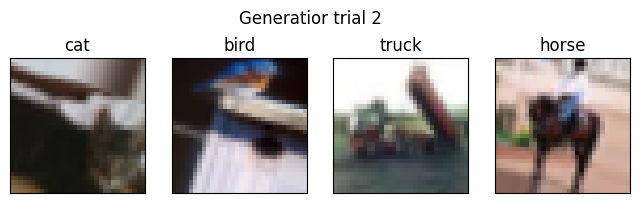

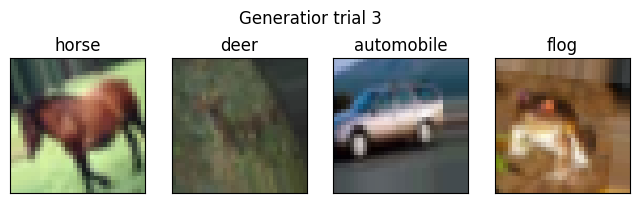

In [ ]:
import tensorflow.keras.datasets as ds
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1) CIFAR-10 데이터셋 불러오기
(x_train, y_train), (x_test, y_test) = ds.cifar10.load_data()

# 2) 데이터 타입 변환 + 정규화 (0~1)
x_train = x_train.astype('float32')
x_train /= 255.0

# 3) 앞 15개 샘플만 증강 테스트용으로 사용
x_train = x_train[0:15]
y_train = y_train[0:15]

# CIFAR-10 클래스 이름
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'flog', 'horse', 'ship', 'truck']

# 4) 원본 15개 이미지 시각화
plt.figure(figsize=(20, 2))
plt.suptitle("First 15 images in the train set")
for i in range(15):
    plt.subplot(1, 15, i + 1)
    plt.imshow(x_train[i])
    plt.xticks([]); plt.yticks([])
    plt.title(class_names[int(y_train[i])])
plt.show()

# 5) ImageDataGenerator 정의: 증강 옵션 설정
generator = ImageDataGenerator(
    rotation_range=20.0,       # 최대 20도까지 회전
    width_shift_range=0.2,     # 가로 이동 최대 20%
    height_shift_range=0.2,    # 세로 이동 최대 20%
    horizontal_flip=True       # 좌우 반전 허용
)

# 6) 증강 제너레이터 생성 (미니배치 크기: 4)
batch_siz = 4
gen = generator.flow(x_train, y_train, batch_size=batch_siz)

# 7) 증강 이미지 3번 만들어서 확인해보기
for a in range(3):
    img, label = gen.next()  # 미니배치 단위로 이미지 증강 생성
    plt.figure(figsize=(8, 2.4))
    plt.suptitle("Generator trial " + str(a + 1))
    for i in range(batch_siz):
        plt.subplot(1, batch_siz, i + 1)
        plt.imshow(img[i])
        plt.xticks([]); plt.yticks([])
        plt.title(class_names[int(label[i])])
    plt.show()
